# Introduction to PK/PD Modeling

## Learning objectives

By the end of this notebook, students should be able to:

- distinguish PK from PD
- explain the meaning of clearance, volume, and absorption rate
- understand why mechanistic PK models are preferable to generic descriptive fits
- fit a simple oral PK model for one subject
- understand the basic idea of a population model
- connect concentration to effect using a simple Emax model


---

## PK versus PD

**Pharmacokinetics (PK)** asks what the body does to the drug.

**Pharmacodynamics (PD)** asks what the drug does to the body.

PK gives us concentration over time. PD maps concentration to effect.


<img src="images/pkpd-diagram.png" width="500" height="500">
https://www.linkedin.com/posts/kroynasdigital_what-is-pkpd-pkpd-stands-for-pharmacokinetics-activity-7262449141551628290-AnQ9/

<img src="images/pkpd-plots-concept.png" width="600" height="500">
https://aneskey.com/2-pharmacokinetic-and-pharmacodynamic-modelling-in-anaesthesia/

## A first PK model: IV bolus elimination

<img src="images/iv_bolus.png" width="400" height="300">

A simple first-order elimination model is

$$\frac{dC}{dt} = -k_e C$$

with analytic solution

$$C(t) = C_0 e^{-k_e t}$$

This gives exponential decay.

A more interpretable way to think about elimination is:

$$k_e = \frac{CL}{V}$$

where **CL** is clearance and **V** is apparent volume of distribution.

<img src="images/iv_bolus.png" width="400" height="300">

---

## Let's introduce the PK dataset

In [12]:
Theoph

,Subject,Wt,Dose,Time,conc
,<ord>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,79.6,4.02,0.00,0.74
2,1,79.6,4.02,0.25,2.84
3,1,79.6,4.02,0.57,6.57
4,1,79.6,4.02,1.12,10.50
5,1,79.6,4.02,2.02,9.66
6,1,79.6,4.02,3.82,8.58
7,1,79.6,4.02,5.10,8.36
8,1,79.6,4.02,7.03,7.47
9,1,79.6,4.02,9.05,6.89


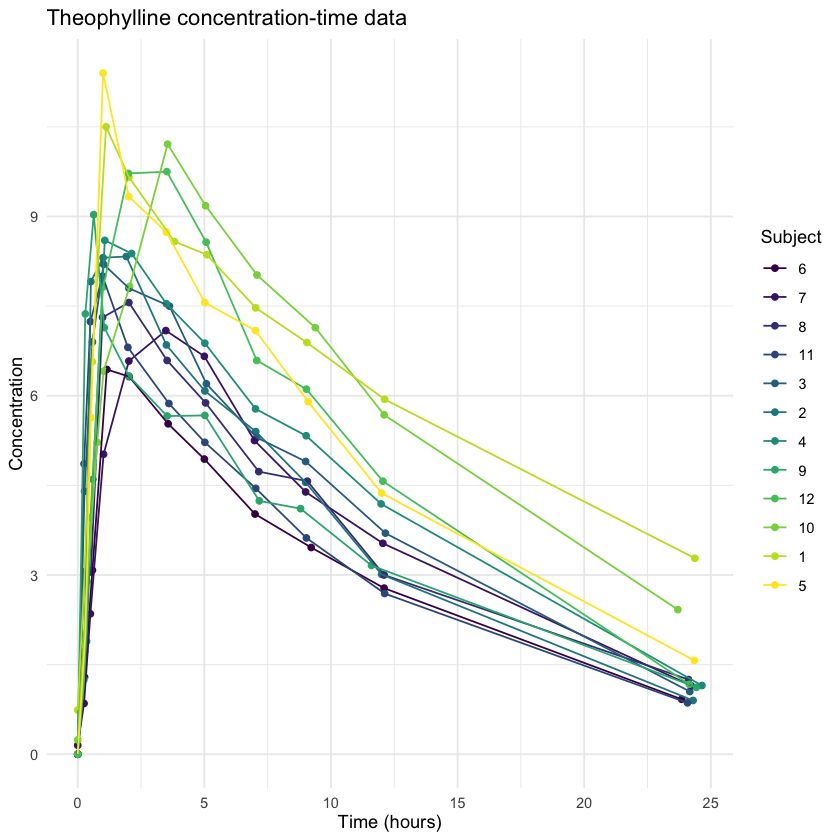

In [13]:
library(ggplot2)

ggplot(Theoph, aes(x = Time, y = conc, group = Subject, color = Subject)) +
  geom_point() +
  geom_line() +
  labs(
    title = "Theophylline concentration-time data",
    x = "Time (hours)",
    y = "Concentration"
  ) +
  theme_minimal()


## Why the simple exponential model is not enough

Theophylline concentrations rise after dosing and then decline. That means absorption must be included, so a simple elimination-only model is not enough.


## One-compartment oral PK model

The analytic solution after a single oral dose is

$$C(t) = \frac{D k_a}{V(k_a-k_e)} \left(e^{-k_e t} - e^{-k_a t}\right)$$

This model is mechanistic because the parameters correspond to biological processes:

- $k_a$: absorption rate
- $CL$: clearance
- $V$: apparent volume
- $k_e = CL/V$: elimination rate


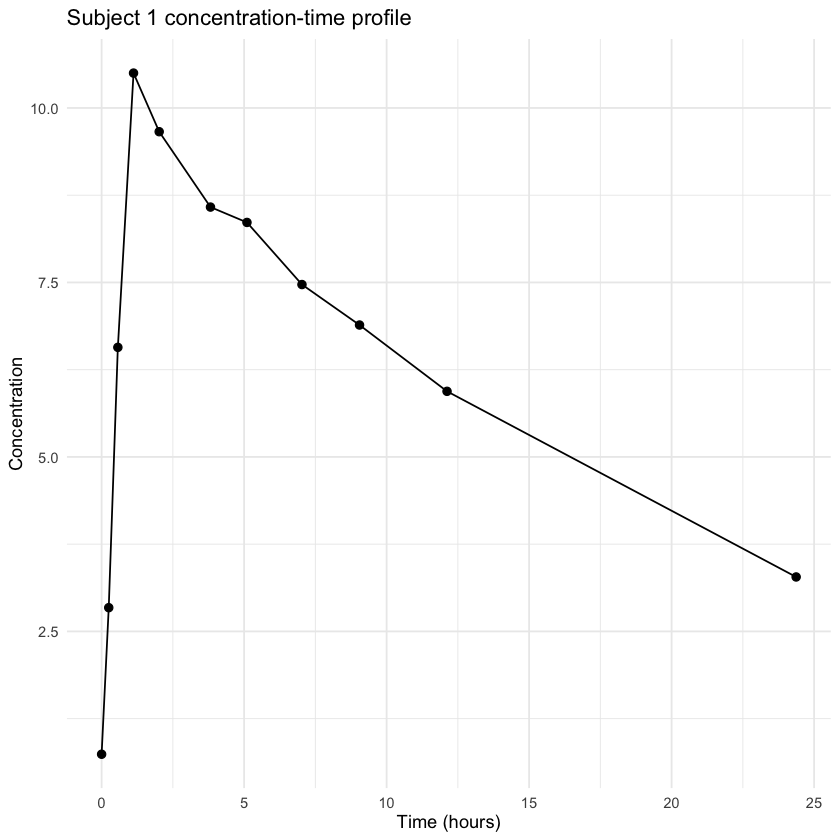

In [3]:
sub1 <- subset(Theoph, Subject == 1)

ggplot(sub1, aes(x = Time, y = conc)) +
  geom_point(size = 2) +
  geom_line() +
  labs(
    title = "Subject 1 concentration-time profile",
    x = "Time (hours)",
    y = "Concentration"
  ) +
  theme_minimal()


## Terminal-phase approximation

A semilog plot of the late phase can help build intuition about elimination, even though it is only an approximation for oral data.


`geom_smooth()` using formula = 'y ~ x'


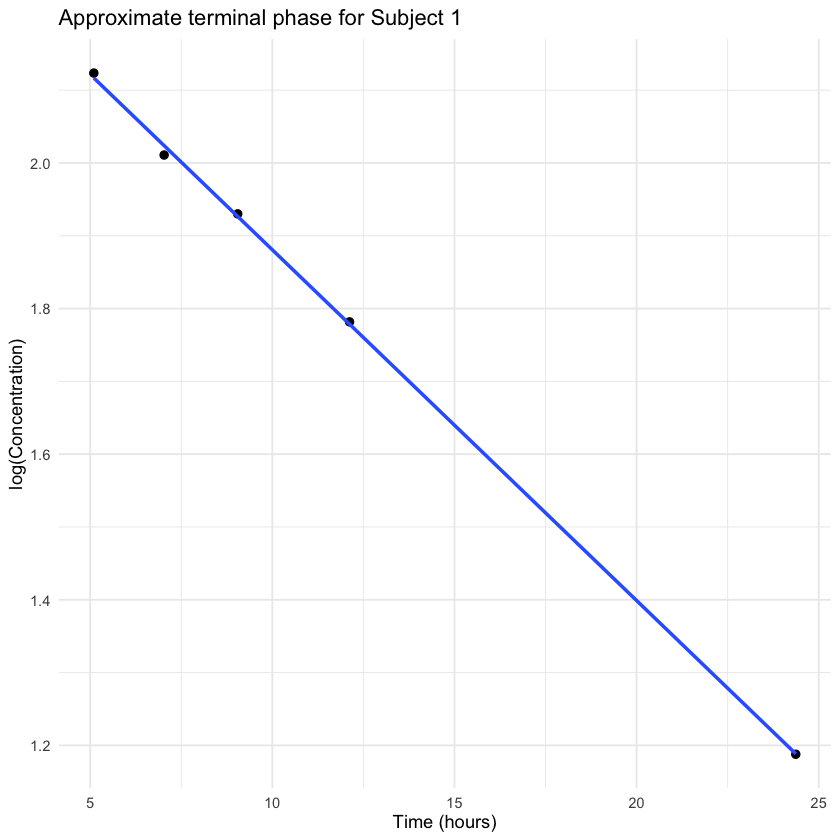

In [4]:
sub1_late <- subset(sub1, Time >= 4)

ggplot(sub1_late, aes(x = Time, y = log(conc))) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Approximate terminal phase for Subject 1",
    x = "Time (hours)",
    y = "log(Concentration)"
  ) +
  theme_minimal()


In [5]:
fit_lm <- lm(log(conc) ~ Time, data = sub1_late)
summary(fit_lm)

ke_hat_lm <- -coef(fit_lm)[["Time"]]
t_half_lm <- log(2) / ke_hat_lm
ke_hat_lm
t_half_lm



Call:
lm(formula = log(conc) ~ Time, data = sub1_late)

Residuals:
         7          8          9         10         11 
 0.0067144 -0.0128741  0.0036126  0.0031434 -0.0005962 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.3624292  0.0077570  304.55 7.81e-08 ***
Time        -0.0481736  0.0005788  -83.23 3.82e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.008834 on 3 degrees of freedom
Multiple R-squared:  0.9996,	Adjusted R-squared:  0.9994 
F-statistic:  6928 on 1 and 3 DF,  p-value: 3.823e-06


[1] 0.04817356

[1] 14.38854

## Mechanistic oral PK model in R

We parameterize the model in terms of log-transformed $k_a$, $CL$, and $V$ so the parameters remain positive.


In [6]:
one_comp_cl <- function(Time, dose, lka, lCL, lV) {
  ka <- exp(lka)
  CL <- exp(lCL)
  V  <- exp(lV)
  k  <- CL / V

  (dose * ka / (V * (ka - k))) *
    (exp(-k * Time) - exp(-ka * Time))
}


In [7]:
sub1$dose <- sub1$Dose

fit_nls_oral <- nls(
  conc ~ one_comp_cl(Time, dose, lka, lCL, lV),
  data = sub1,
  start = list(lka = log(1), lCL = log(0.04), lV = log(0.5)),
  control = nls.control(maxiter = 200, warnOnly = TRUE)
)

summary(fit_nls_oral)



Formula: conc ~ one_comp_cl(Time, dose, lka, lCL, lV)

Parameters:
    Estimate Std. Error t value Pr(>|t|)    
lka  0.57516    0.17282   3.328   0.0104 *  
lCL -3.91586    0.12727 -30.768 1.35e-09 ***
lV  -0.99624    0.06022 -16.543 1.80e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.732 on 8 degrees of freedom

Number of iterations to convergence: 12 
Achieved convergence tolerance: 3.094e-06


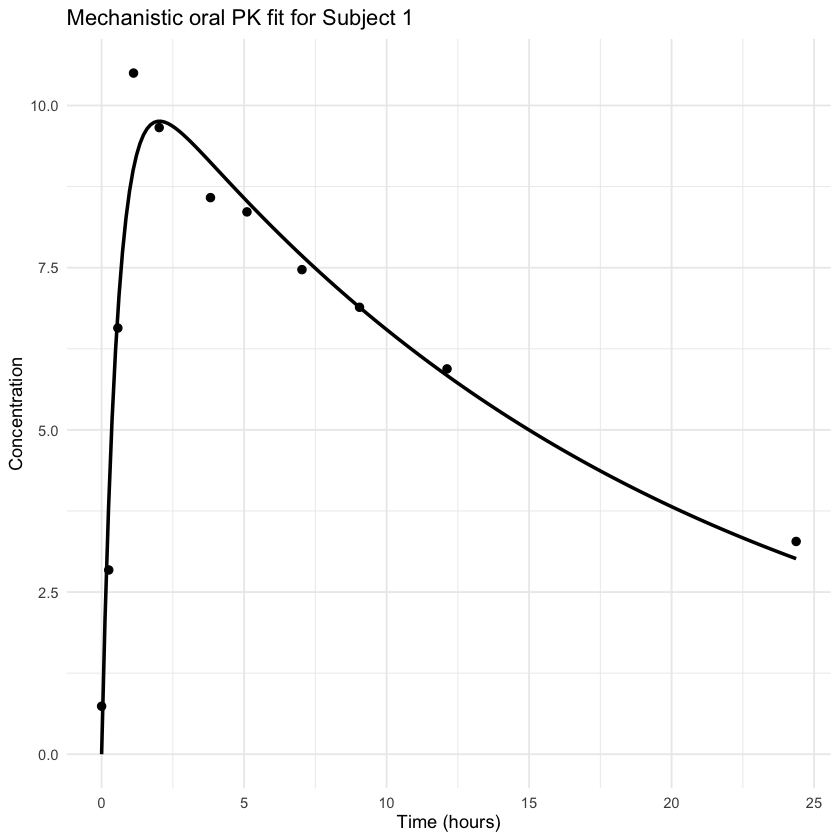

In [8]:
time_grid_sub1 <- data.frame(
  Time = seq(min(sub1$Time), max(sub1$Time), length.out = 200),
  dose = unique(sub1$Dose)[1]
)
time_grid_sub1$pred <- predict(fit_nls_oral, newdata = time_grid_sub1)

ggplot(sub1, aes(x = Time, y = conc)) +
  geom_point(size = 2) +
  geom_line(data = time_grid_sub1, aes(x = Time, y = pred), linewidth = 1) +
  labs(
    title = "Mechanistic oral PK fit for Subject 1",
    x = "Time (hours)",
    y = "Concentration"
  ) +
  theme_minimal()


## Population models: concept first

In biomedical data, individuals differ. Mixed-effects models allow us to represent both the average behavior in the population and variability between people.

For this first lecture, the idea is more important than the software details.


In [9]:
# Illustration only; not required to run during lecture
# library(nlme)
# theoph_data <- Theoph
# theoph_data$dose <- theoph_data$Dose
# start_list <- c(lka = log(1), lCL = log(0.04), lV = log(0.5))
# environment(one_comp_cl) <- .GlobalEnv
# f <- conc ~ one_comp_cl(Time, dose, lka, lCL, lV)
# environment(f) <- .GlobalEnv
# nlme_model <- nlme(
#   f,
#   data = theoph_data,
#   fixed  = lka + lCL + lV ~ 1,
#   random = lCL + lV ~ 1 | Subject,
#   start  = start_list
# )


## A simple PD model: Emax

To keep the PD section simple, we create synthetic effect data directly from concentration using an Emax model:

$$E(C) = \frac{E_{max} C}{EC_{50} + C}$$

This shows a direct saturable concentration-effect relationship.


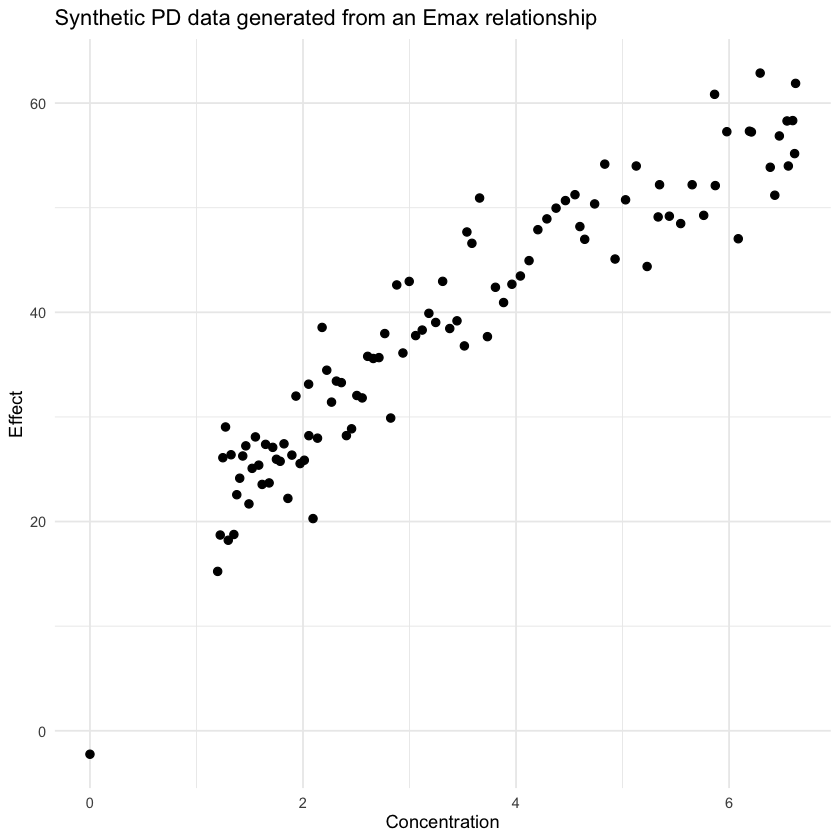

In [10]:
time_grid <- data.frame(
  Time = seq(min(Theoph$Time), max(Theoph$Time), length.out = 100)
)

Dose_demo <- unique(Theoph$Dose)[1]
ka_demo <- 1.2
CL_demo <- 0.04
V_demo  <- 0.5
ke_demo <- CL_demo / V_demo

pk_oral <- function(t, Dose, V, ka, ke) {
  (Dose * ka / (V * (ka - ke))) * (exp(-ke * t) - exp(-ka * t))
}

time_grid$conc <- pk_oral(time_grid$Time, Dose_demo, V_demo, ka_demo, ke_demo)

set.seed(123)
Emax_true <- 100
EC50_true <- 5

pd_dat <- time_grid
pd_dat$effect <- Emax_true * pd_dat$conc / (EC50_true + pd_dat$conc) +
  rnorm(nrow(pd_dat), sd = 4)

ggplot(pd_dat, aes(x = conc, y = effect)) +
  geom_point(size = 2) +
  labs(
    title = "Synthetic PD data generated from an Emax relationship",
    x = "Concentration",
    y = "Effect"
  ) +
  theme_minimal()



Formula: effect ~ Emax * conc/(EC50 + conc)

Parameters:
     Estimate Std. Error t value Pr(>|t|)    
Emax  95.9133     4.4217   21.69   <2e-16 ***
EC50   4.5685     0.3918   11.66   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.658 on 98 degrees of freedom

Number of iterations to convergence: 3 
Achieved convergence tolerance: 5.547e-07


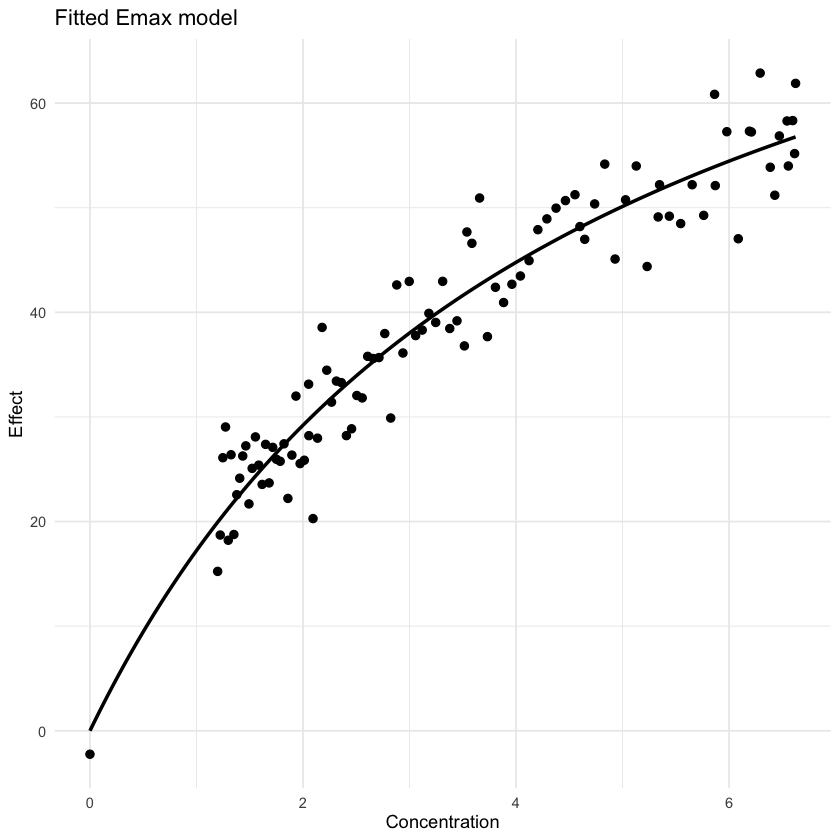

In [11]:
fit_emax <- nls(
  effect ~ Emax * conc / (EC50 + conc),
  data = pd_dat,
  start = list(Emax = 100, EC50 = 5),
  control = nls.control(maxiter = 200, warnOnly = TRUE)
)

summary(fit_emax)

conc_grid <- data.frame(
  conc = seq(min(pd_dat$conc), max(pd_dat$conc), length.out = 200)
)
conc_grid$effect_hat <- predict(fit_emax, newdata = conc_grid)

ggplot(pd_dat, aes(x = conc, y = effect)) +
  geom_point(size = 2) +
  geom_line(data = conc_grid, aes(x = conc, y = effect_hat), linewidth = 1) +
  labs(
    title = "Fitted Emax model",
    x = "Concentration",
    y = "Effect"
  ) +
  theme_minimal()


## Assignment ideas

1. Plot concentration versus time for all subjects.
2. Choose one subject and describe the shape of the curve.
3. Fit a terminal-phase linear model and estimate half-life.
4. Fit a mechanistic oral PK model for one subject.
5. Explain in plain language why a mechanistic model is preferable to a generic biexponential fit.
6. As a stretch, generate a simple synthetic PD dataset and fit an Emax model.


## Reproducibility with renv

You will receive a repository with the materials. To install packages, run:

```r
install.packages("renv")
renv::restore()
```


## Closing thought

PK/PD modeling is not just curve fitting. It is a way to express biological hypotheses quantitatively and to test whether those hypotheses are consistent with data.
